# Reto: Tercer Avance
## Spaceship Titanic

### Inteligencia Artificial Avanzada para la Ciencia de Datos

---

**Integrantes**

- Ana Paula Moreno
- David Tinoco Romero
- Emilio Páez de la Mora
- Alejandro Vázquez
- Emilio Torres

---

### Tecnológico de Monterrey

---

## Objetivo del notebook

Este notebook documenta el tercer avance del reto **Spaceship Titanic**: partiendo del
mejor modelo identificado en el segundo avance (Random Forest, `n_estimators=200`,
`max_depth=10`), se diagnostica su comportamiento con curvas de aprendizaje y de
validación, se afina mediante búsqueda de hiperparámetros con validación cruzada
(K-Fold), y se evalúa el modelo tuneado contra el baseline y el modelo del avance
anterior. Cada integrante del equipo explora además, de forma independiente, un
modelo de una familia distinta a la usada por el equipo. Finalmente se exporta el
modelo final, se genera el archivo de submission para Kaggle y se cierra con las
conclusiones del equipo sobre los tres avances.

El notebook está organizado en las siguientes secciones:

1. Diagnóstico del Modelo Base
2. Tuning de Hiperparámetros
3. Evaluación Final
4. Componente Individual
5. Exportar Modelo y Submission
6. Conclusión Final del Equipo

**Nota sobre continuidad respecto al segundo avance:** este notebook retoma
directamente el dataset preprocesado (`spaceship_train_procesado.csv`) y el split
`X_train`/`X_test`/`y_train`/`y_test` usados en el segundo avance, así como las
métricas ya definidas (Accuracy, Precision, Recall, F1-score), para que el
diagnóstico y el tuning de la Sección 1 y 2 sean comparables directamente contra
los resultados del Random Forest reportado como mejor modelo en el avance anterior.

# 1. Diagnóstico del Modelo Base

Antes de tunear hiperparámetros, diagnosticamos el comportamiento del mejor
modelo del segundo avance (Random Forest, `n_estimators=200`, `max_depth=10`)
con dos herramientas:

- **Curva de aprendizaje**: muestra cómo cambia el desempeño en entrenamiento
  y en validación conforme aumenta el tamaño del conjunto de entrenamiento.
  Nos dice si el modelo sufre de underfitting, overfitting, o si le
  serviría tener más datos.
- **Curvas de validación**: muestran cómo cambia el desempeño conforme
  variamos un hiperparámetro a la vez, manteniendo los demás fijos. Nos
  ayudan a ver en qué rango tiene sentido buscar durante el tuning
  (Sección 2).

Usamos `cross_val_score` con validación cruzada (no solo el split
train/test fijo) para que las curvas reflejen la variabilidad del modelo,
no un solo split particular.

## Nota sobre preparación: persistencia del split y del modelo del avance 2

Al arrancar este tercer avance detectamos que, igual que pasó con `df_prep` en
el primer avance, el split `X_train/X_test/y_train/y_test` y el modelo
`modelo_rf` entrenado en el segundo avance solo existían en memoria dentro de
ese notebook. Esto impedía diagnosticar y comparar contra el modelo del avance
anterior de forma reproducible sin volver a correr todo el notebook 2.

**Corrección aplicada:** al final del notebook del segundo avance agregamos
celdas que guardan el split (`X_train.csv`, `X_test.csv`, `y_train.csv`,
`y_test.csv`) y el modelo entrenado (`modelo_rf_avance2.pkl`) en la carpeta
`data/`. En este notebook cargamos esos archivos directamente, en vez de
repetir el split y el entrenamiento.

In [8]:
import pandas as pd
import joblib
from pathlib import Path

DATA = Path("..") / "data"
RANDOM_STATE = 42

X_train = pd.read_csv(DATA / "X_train.csv")
X_test = pd.read_csv(DATA / "X_test.csv")
y_train = pd.read_csv(DATA / "y_train.csv").squeeze("columns")
y_test = pd.read_csv(DATA / "y_test.csv").squeeze("columns")

modelo_rf = joblib.load(DATA / "modelo_rf_avance2.pkl")

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Hiperparámetros del modelo cargado:", modelo_rf.get_params())

X_train: (6954, 26) X_test: (1739, 26)
Hiperparámetros del modelo cargado: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


**¿Por qué usamos F1-score como métrica en las curvas?**

Para curvas de diagnóstico conviene fijar una sola métrica escalar y comparable
punto a punto. Elegimos F1-score (en vez de accuracy) porque:

- Resume en un solo número el balance entre precision y recall, que en el
  avance 2 vimos que se mueven en direcciones opuestas al cambiar
  hiperparámetros de Random Forest (por ejemplo, al subir `min_samples_leaf`
  el recall subía pero la precision bajaba). Usar accuracy podría ocultar ese
  trade-off, ya que dos configuraciones con accuracy parecido pueden tener
  perfiles de error muy distintos.
- Es la métrica que el equipo usó en el avance 2 para tomar la decisión final
  entre modelos (Sección 6), así que mantenerla aquí hace que el diagnóstico
  de la Sección 1 sea directamente comparable con esa decisión.
- Aunque el dataset está prácticamente balanceado (~50.4%/49.6%), por lo que
  accuracy no estaría "inflado" artificialmente, F1 sigue siendo más
  informativo cuando se comparan muchos puntos de una curva, porque no se
  puede inspeccionar la matriz de confusión de cada uno.

In [9]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
import numpy as np

modelo_base = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)

train_sizes, train_scores, val_scores = learning_curve(
    modelo_base,
    X_train, y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print("Tamaños de entrenamiento:", train_sizes)
print("F1 promedio (train):", np.round(train_mean, 4))
print("F1 promedio (val):", np.round(val_mean, 4))

Tamaños de entrenamiento: [ 556 1271 1986 2702 3417 4132 4847 5563]
F1 promedio (train): [0.9738 0.9368 0.917  0.8971 0.8848 0.878  0.8748 0.8714]
F1 promedio (val): [0.7784 0.7793 0.7888 0.7922 0.7957 0.8012 0.8025 0.8061]


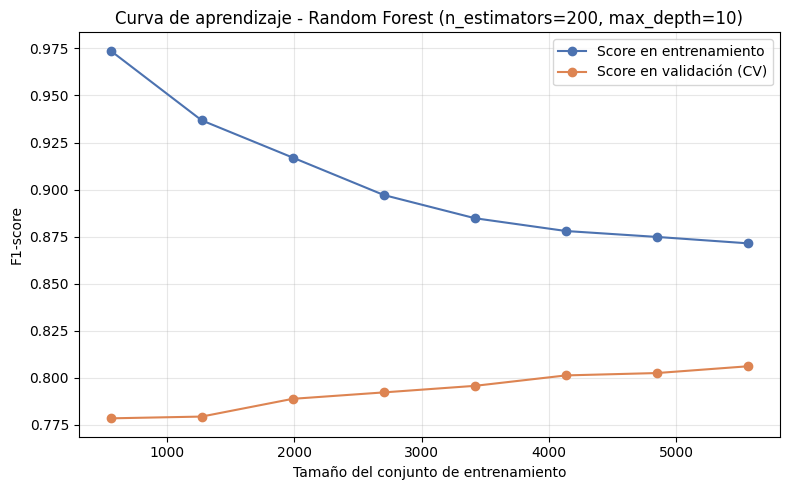

In [10]:
#visualizar curva de aprendizaje
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(train_sizes, val_mean, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("F1-score")
plt.title("Curva de aprendizaje - Random Forest (n_estimators=200, max_depth=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La curva de aprendizaje muestra dos comportamientos:

- El score en **entrenamiento** empieza muy alto (0.974 con ~556 muestras) y
  **baja progresivamente** conforme agregamos más datos, hasta 0.871 con el
  conjunto completo (~5563 muestras).
- El score en **validación** empieza bajo (0.778) y **sube progresivamente**
  hasta 0.807.

La brecha entre ambas curvas se reduce de ~0.20 a ~0.065, pero **no llega a
cerrarse del todo** : incluso con todos los datos disponibles, el modelo sigue
ajustándose bastante mejor a los datos que ya vio que a datos nuevos.

**Diagnóstico:**

- **Sí hay overfitting**, aunque moderado y decreciente. Con `max_depth=10`
  y `n_estimators=200`, los árboles siguen teniendo capacidad suficiente para
  memorizar parte del ruido de entrenamiento en vez de solo el patrón general.
- **No parece ser un problema de underfitting**: el score de validación va
  mejorando de forma consistente conforme crece el dataset, no se estanca
  desde el inicio en un valor bajo y plano.
- **¿Ayudaría más data?** La curva de validación todavía tiene pendiente
  positiva al final (no se ha aplanado por completo), así que en principio
  más datos seguirían ayudando un poco. Sin embargo, la pendiente ya es
  pequeña entre los últimos puntos (de 0.803 a 0.807), así que el margen de
  mejora solo por agregar más filas parece limitado — no tenemos control
  sobre esto de todas formas, ya que el tamaño de `train.csv` es fijo.
- **Implicación para el tuning (Sección 2):** como la brecha train-val viene
  del lado del overfitting, tiene sentido explorar hiperparámetros que
  **limiten la complejidad del árbol individual** (`max_depth` más bajo o
  igual, `min_samples_leaf` y `min_samples_split` más altos) en vez de
  buscar modelos más complejos. También conviene revisar `n_estimators`,
  aunque el avance 2 ya sugirió que subir de 200 a 500 no cambiaba mucho el
  desempeño.

In [11]:
#Curva de validación par amax_depth 

from sklearn.model_selection import validation_curve

rango_max_depth = [3, 5, 7, 10, 13, 16, 20, None]

train_scores_md, val_scores_md = validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    X_train, y_train,
    param_name="max_depth",
    param_range=rango_max_depth,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

train_mean_md = train_scores_md.mean(axis=1)
val_mean_md = val_scores_md.mean(axis=1)

print("max_depth:", rango_max_depth)
print("F1 promedio (train):", np.round(train_mean_md, 4))
print("F1 promedio (val):", np.round(val_mean_md, 4))

max_depth: [3, 5, 7, 10, 13, 16, 20, None]
F1 promedio (train): [0.7187 0.7665 0.8184 0.8715 0.9317 0.9767 0.9881 0.9882]
F1 promedio (val): [0.7181 0.7563 0.7896 0.806  0.7996 0.792  0.7896 0.7907]


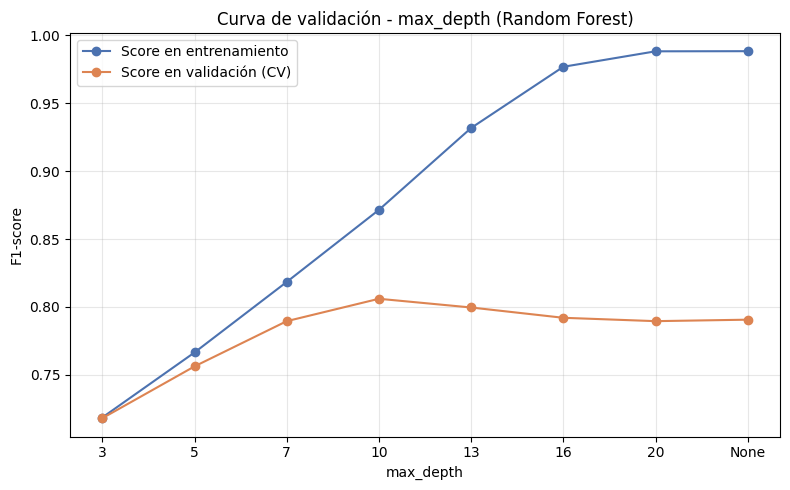

In [12]:
#graficar curva 

etiquetas_md = [str(v) for v in rango_max_depth]  # para que "None" se vea bien en el eje x

plt.figure(figsize=(8, 5))
plt.plot(etiquetas_md, train_mean_md, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(etiquetas_md, val_mean_md, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("max_depth")
plt.ylabel("F1-score")
plt.title("Curva de validación - max_depth (Random Forest)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
rango_min_leaf = [1, 2, 5, 10, 20, 30, 50]

train_scores_ml, val_scores_ml = validation_curve(
    RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
    X_train, y_train,
    param_name="min_samples_leaf",
    param_range=rango_min_leaf,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

train_mean_ml = train_scores_ml.mean(axis=1)
val_mean_ml = val_scores_ml.mean(axis=1)

print("min_samples_leaf:", rango_min_leaf)
print("F1 promedio (train):", np.round(train_mean_ml, 4))
print("F1 promedio (val):", np.round(val_mean_ml, 4))

min_samples_leaf: [1, 2, 5, 10, 20, 30, 50]
F1 promedio (train): [0.8715 0.86   0.8464 0.8325 0.8201 0.811  0.795 ]
F1 promedio (val): [0.806  0.8074 0.8061 0.8027 0.7985 0.7896 0.7817]


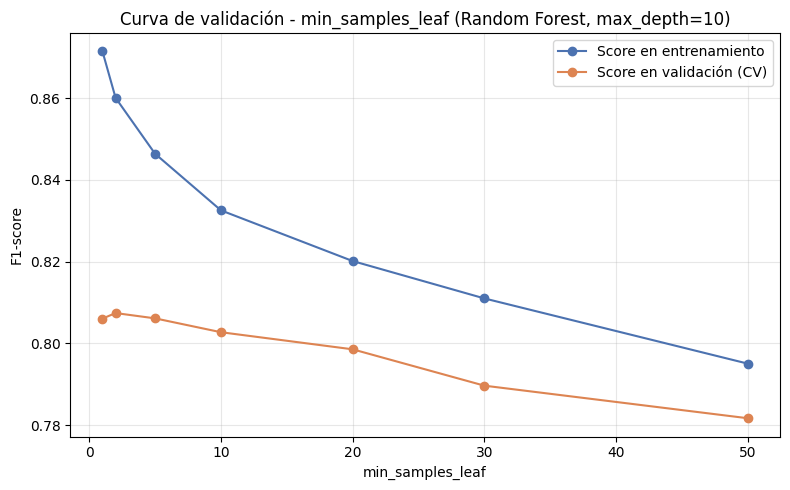

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(rango_min_leaf, train_mean_ml, "o-", color="#4C72B0", label="Score en entrenamiento")
plt.plot(rango_min_leaf, val_mean_ml, "o-", color="#DD8452", label="Score en validación (CV)")

plt.xlabel("min_samples_leaf")
plt.ylabel("F1-score")
plt.title("Curva de validación - min_samples_leaf (Random Forest, max_depth=10)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretación de las curvas de validación

**`max_depth`:** la curva muestra un pico claro de generalización en
`max_depth=10` (F1 val = 0.806). Antes de ese punto (3 a 7) el modelo está en
zona de **underfitting**: train y val suben juntos porque el árbol es
demasiado simple para capturar el patrón. Después de 10, el train sigue
subiendo hasta casi memorizar el dataset (0.988 en `max_depth=20` y `None`)
mientras el val se estanca e incluso baja un poco (0.79-0.80) — es decir,
**overfitting creciente sin beneficio**. Esto confirma que `max_depth=10`,
el valor ya usado en el avance 2, es efectivamente un buen punto de
equilibrio, y no un valor arbitrario.

**`min_samples_leaf`:** aquí el comportamiento es distinto. El train baja de
forma constante conforme aumenta `min_samples_leaf` (0.8715 → 0.795), y el
val se mantiene casi plano entre 1 y 5 (0.806-0.807) para luego empezar a
bajar de forma más clara a partir de 10 (0.803 → 0.782 en `leaf=50`). A
diferencia de `max_depth`, aquí **no hay un pico donde el val mejore** al
reducir la complejidad: la brecha train-val sí se cierra (de 0.065 a 0.013),
pero porque el train empeora, no porque el val mejore. Esto es consistente
con lo que Emilio Páez observó en el avance 2 al subir `min_samples_leaf` de
1 a 5: el F1 casi no cambió (+0.0002), solo cambió el tipo de error
(precision vs recall).

**Diagnóstico combinado:**

- El overfitting detectado en la curva de aprendizaje viene principalmente
  de `max_depth`, no de `min_samples_leaf`. Este último hiperparámetro
  regulariza el modelo, pero en este dataset no se traduce en mejor
  generalización, solo en un modelo más simple con desempeño similar o peor.
- **Rango a explorar en el tuning (Sección 2):**
  - `max_depth`: valores alrededor de 10 (por ejemplo, 8 a 14), ya que es
    donde está el pico; no tiene sentido incluir valores muy altos o `None`,
    porque ya vimos que solo generan overfitting sin ganancia.
  - `min_samples_leaf`: valores bajos (1 a 5), ya que es la zona donde el
    val se mantiene en su mejor nivel; valores mayores a 10 se pueden
    excluir, porque la curva muestra una caída consistente sin recuperación.
  - Vale la pena agregar `n_estimators` y `min_samples_split` a la grilla
    aunque no se graficaron aquí, ya que interactúan con `max_depth` y
    podrían desplazar ligeramente el punto óptimo cuando se combinan (por
    eso el tuning se hace con búsqueda conjunta y no solo curva por curva).

# 2. Tuning de Hiperparámetros

En la Sección 1 identificamos, con evidencia empírica (no a ciegas), en qué
rango tiene sentido buscar: `max_depth` alrededor de 10 y `min_samples_leaf`
en valores bajos (1-5). En esta sección usamos esa evidencia para afinar el
modelo de forma más sistemática, cubriendo:

- **Elección del método de búsqueda** (GridSearchCV vs RandomizedSearchCV),
  justificada según el tamaño del espacio de búsqueda resultante de combinar
  varios hiperparámetros a la vez.
- **La grilla o distribución de hiperparámetros**, anclada directamente a los
  rangos observados en las curvas de validación de la Sección 1, en vez de
  valores arbitrarios.
- **K-Fold dentro de la búsqueda**, con una K justificada (no necesariamente
  la misma que usamos para trazar las curvas de diagnóstico).
- **Los mejores hiperparámetros encontrados** y el score obtenido en
  validación cruzada.
- **Al menos dos métricas de evaluación**, justificadas con base en las
  características del dataset — retomando el balance de clases (~50.4% /
  49.6%) y el trade-off precision/recall que ya se discutió en el avance 2.

El objetivo no es solo encontrar el mejor score posible, sino verificar si el
modelo tuneado mejora de forma real sobre el Random Forest del avance 2, o si
—como ya insinuaban las curvas de `min_samples_leaf`— el margen de mejora
disponible es pequeño.